# Outlier detection algorithms

This notebook is dedicated to the implementation and testing of algorithms detecting outliers in a dataset.

**An outlier is not a novelty, they are related but different concept. An outlier can lie in the training dataset, whereas a novelty is a new observation that could be considered a outlier.**

## One-Class SVM (OC-SVM)

Let $\mathcal{X}$ be the space where data lives, and $d=\text{dim}(\mathcal{X})$. Data points are assumed to be the realization of a probability measure noted $\mathbb{P}$. We introduce the quantile function for a real-valued function $\lambda$ on measurable subsets $\mathcal{C}$ of $\mathcal{X}$: $U(\alpha)=\inf\limits_{C \in \mathcal{C}} \{\lambda (C)\backslash \mathbb{P}(C) \geq \alpha \}$, where $\alpha \in ]0, 1]$. We note $C(\alpha)$ the set that reaches the infimum for a level $\alpha$. $\lambda$ is usually the Lebesgue measure, in which case, it identifies to the generalized inverse distribution function. [1] describes an algorithm which finds regions close to $C(\alpha)$. A first idea could be to use the set separating hyperplanes $(H_{w, \rho})_{w \in \mathbb{R}^d, \rho \in \mathbb{R}}$ of general form: $H_{w, \rho}=\{x \backslash \, (w, x)_{\mathbb{R}^d} \geq \rho\}$, to find regions close to $C(\alpha)$. The optimization problem below should not be interpreted as assuming that the origin has a statistical meaning. The statistical objective is to estimate a minimum-volume set containing a prescribed probability mass. The separation from the origin only appears after reformulating the support estimation problem as a large-margin classification problem in the RKHS.

Excluding some potential kernel parameters, the OC-SVM has a single free parameter $\nu \in ]0, 1]$ that can be challenging to correctly tune.

For more generality, we should employ kernel machinery to map the data space $\mathcal{X}$ to the feature space $\mathcal{H}$ via a chosen feature map $\Phi$. Separating hyperplanes are then built in the feature space: $C_{w, \rho}=\{x \in \mathcal{X} \backslash \, (\Phi(x), w)_{\mathcal{H}}\geq \rho\}$; the major interest being that they translates into regions with nonlinear borders back in data space.

Take a dataset $x_1, \cdots, x_n \in \mathcal{X}$.

The objective is to present an algorithm that identifies a function $f$ taking the value $+1$ in 'small' regions that capture most of the data points and $-1$ elsewhere. The decision rule is to declare a point $x$ as an outlier if $f(x)=-1$. $f$ is chosen to be parameterized as $f(x)=\text{sgn}((w,x)-\rho)$, and the optimization problem to find optimal parameters $(w, \rho)$ is:


\begin{align*}
\min\limits_{w\in\mathcal{H}, \rho \in \mathbb{R}} & \frac12 ||w||_2^2 + \frac1{\nu n} \sum\limits_i \xi_i - \rho \\
\text{s.t} &\,\, (w, \Phi(x_i))\geq \rho-\xi_i \, \forall i \in \{1, \cdots ,n\},\\
& \xi_i \geq 0 \, \forall i \in \{1, \cdots ,n\}.
\end{align*}

If $\nu$ tends towards $0$, it becomes the hard margin problem $\forall i, \xi_i=0$, i.e., no outlier is allowed in the training dataset. It always remains feasible though, since $\rho$ is not lower-bounded. More precisely, $\nu$ is an upper bound on the number of outliers and a lower bound on the number of support vector.

The lagrangian of the primal problem is:
$$
\mathcal{L}(w, \rho, \alpha, \beta)=\frac12 ||w||_2^2 + \frac1{\nu n} \sum\limits_i \xi_i - \rho - \alpha\cdot (f(x_i)-\rho + \xi_i) - \beta \cdot \xi,
$$
where $\alpha, \beta\in\mathbb{R}^n$ are the Lagrange multipliers. Eliminating $\beta$, $w$ and $\rho$ yields the dual problem:
\begin{align*}
\min\limits_{\alpha \in \mathbb{R}^n} & \frac12 \sum\limits_{i,j=1}^n \alpha_i \alpha_j k(x_i, x_j) \\
\text{s.t} &\,\, 0\leq \alpha_i \leq \frac{1}{\nu n} \, \forall i \in \{1, \cdots ,n\},\\
& \sum\limits_{i=1}^n \alpha_i=1.
\end{align*}

Because the primal problem is convex, $(P) \iff (D)$.

After solving this problem, hyperplane parameters are $w=\sum\limits_{i=1}^n \alpha_i \Phi(x_i)$, and $\rho=(w, \Phi(x_i))=\sum\limits_{j=1}^n \alpha_j k(x_i, x_j)$ for any index $i$ such that $\alpha_i \in ]0, \frac1{\nu n}[$. We noted $k(x_i, x_j)=(\Phi(x_i), \Phi(x_j))_{\mathcal{H}}$. The complementary slackness of the KKT equations says that $O_i=\rho \iff 0<\alpha_i<\frac 1{\nu n}$. Those are the points that draw the margin between outliers and inliers.

It is important to note that the origin $(0, 0)$ plays a key role in the algorithm. The One-Class SVM tries to find an hyperplane that separates the dataset from the origin with the largest margin and interceipt. However, the parameter $\nu$ controls the portion of outlier allowed. when $||w||^2$ penalises too much the objective function to include all data points, the SVM allows outliers with a penalisation cost of the order of $\frac{1}{\nu n}$, a compromise must be found.

The hard-margin problem (when $\nu \rightarrow 0$) always admits a solution for certain kernels, such as the rbf.

Unlike density estimation methods, the OC-SVM never estimates the density itself. Instead, it estimates one of its upper level sets through a maximum-margin principle in the RKHS.


### Quadratic Optimization algorithm

To solve this QP problem, one could use an off-the-shell solver, with time complexity scaling as $\mathcal{O}(n^3)$. Instead, [1] proposes an alternate version of *Sequential Minimal Optimization* (SMO), published in [2], to take advantage of the simplicity of the constraints and better scale with the size of dataset $n$.

We define the output of data $i$ as: $f(x_i)=O_i=\langle w, \Phi(x_i)\rangle$.

At initialisation, not index pair is selected yet. A fraction of entries chosen at random from $\alpha$ are set to $\frac1{\nu n}$, and the remaining entries are set to $0$. By the complementary condition, their Lagrange multiplier $\xi_i$ of the null entries are positive, meaning they are initialized as outliers since they lie out of the hyperplane. The initial $\rho$ is set to $\max\limits_{i}\{(O_i)_{i\in \llbracket 1, n\rrbracket}, \alpha_i>0\}$, with $O_i$ defined below. In order to find the optimal solution, the algorithm interacts with two non-exclusive types of points: KKT violators (i.e. points that do not satisfy the KKT complementary slackness) and support vectors, which define the hyperplane border and satisfy the condition $0 < \alpha_i < \frac{1}{\nu n}$. More precisely, a point $x_i$ violates KKT complementary slackness if its Lagrange multiplier $\alpha_i$:
$$
\alpha_i(O_i-\rho)>0 \quad \, \text{or} \quad \, (C-\alpha_i)(\rho-O_i)>0.
$$

You must choose a pair of indices, $i_1$ and $i_2$, from among the KKT violators and then update the corresponding Lagrange multipliers, $\alpha_{i_1}$ and $\alpha_{i_2}$, iteratively. The heuristics used to select $i_1$ and $i_2$ have become increasingly refined since the original algorithm was published [1]. The choice heuristics used in the high-end implementations provided by sklean and LIBSVM are far more sophisticated than those implemented here. I implement below the ones presented in [1], although they are largely outdated now.

The other indices of variables $i\neq i_1, i_2$ are kept fixed, and the inequality constraints are ignored first. One finds the following update rule for $\alpha_{i_2}$:

$$
\alpha_{i_2}^{(t+1)}=\frac{\Delta (K_{i_1,i_1} - K_{i_2,i_2}) + C_{i_1} - C_{i_2}}{K_{i_1, i_1}+K_{i_2, i_2} - 2K_{i_1, i_2}},\\
$$

However, nothing ensure $\alpha_{i_2}$ to remain bounded between $0$ and $\frac 1{\nu n}$, i.e. feasible. The remedy is a projection onto the admissible set $\{\alpha_{i_1}, \alpha_{i_2} \backslash \alpha_{i_1}, \alpha_{i_2} \in [0, C], \alpha_{i_1}+\alpha_{i_2}=\Delta\}.$ After carefully considering the situation, $\alpha_{i_2}^{(t+1)}$ is clipped in the interval: $[\min(0, \Delta-C), \max(C, \Delta)]$. The equality constraint uniquely determine $\alpha_{i_1}^{(t+1)}$.

$$
\alpha_{i_1}^{(t+1)}=\Delta - \alpha_{i_2}^{(t+1)},
$$

where $\Delta=1-\sum\limits_{i \neq \{i_1, i_2\}}\alpha_i$, $K_{i,  j}=K(x_{i}, x_{j})$.

In particular, extracting the updated variable $\alpha_{i_1}$, $\alpha_{i_2}$ from the sum, the $i-$ th output can be written: $O_{i}=K_{ii_1}\alpha_{i_1} + K_{ii_2}\alpha_{i_2} + C_i ,\, C_i=\sum\limits_{j\notin \{i_1, i_2\}} \alpha_j K_{i,j}$.

[1] [Estimating the Support of a High-Dimensional Distribution](https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/tr-99-87.pdf)

[2] [Sequential Minimal Optimization: A Fast Algorithm for Training Support Vector Machines](https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/tr-98-14.pdf)

Convergence in 42 iterations.
nu=0.1
----------------------------My One-Class SVM---------------------------
rho=  9.837936928845048
[0.0990099  0.0990099  0.0990099  0.0990099  0.00990099 0.0990099
 0.0990099  0.0990099  0.0990099  0.0990099  0.0990099 ]
Point at [-10.36918184 -10.23937918] should be an outlier:  [-1]
Points that should be an inlier:  [ 1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1 -1 -1  1  1  1  1
  1  1  1  1]
--------------------------Sklearn One-Class SVM------------------------
rho=  -99.36316165924029
[[1.  1.  1.  1.  0.1 1.  1.  1.  1.  1.  1. ]]
Point at [-10.36918184 -10.23937918] should be an outlier:  [-1]
Points that should be an inlier:  [ 1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1 

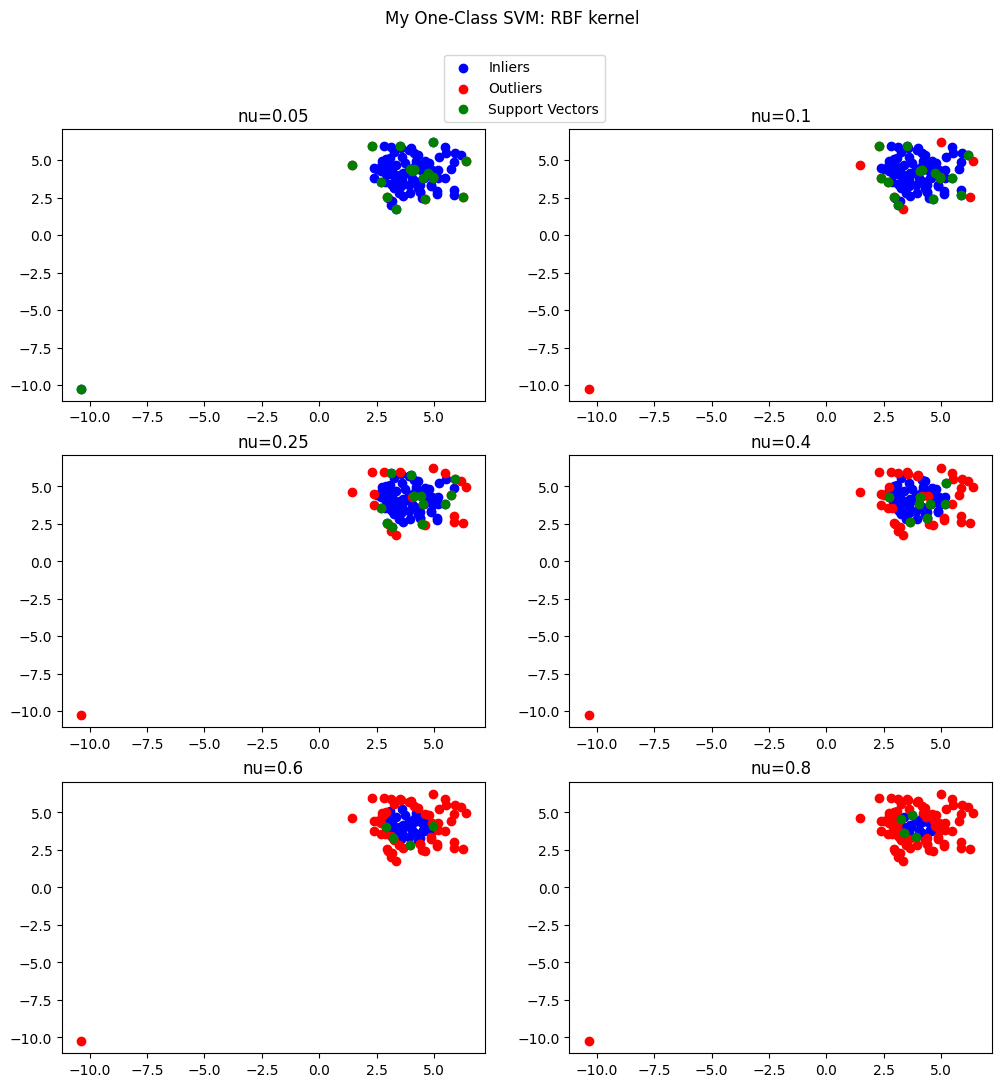

In [8]:
import numpy as np
from typing import Callable
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM


def linear(x, y):
    return np.einsum('ik,jk -> ij', x, y)

def RBF(sigma: float=1.):
    assert sigma>0
    def kernel(x, y):
        return np.exp(-np.sum((x[:,None]-y[None])**2, axis=-1)/(2*sigma**2))
    return kernel

class One_class_SVM:
    def __init__(self, nu: float, kernel: Callable, *, max_iter: int=1000, epsilon=1e-8):
        assert nu>0 and nu<1, "nu should be positive"
        self.nu=nu
        self.kernel=kernel
        self.Gram=None
        
        self.X=None #Data

        self.max_iter=max_iter

        self.epsilon=epsilon
    
    def init(self, ln: int):
        """
        Initialize Lagrange multipliers (alpha_i)_i
        ln: Amount of training points.
        """
        alpha=np.zeros(ln)
        alpha[:int(ln*self.nu)]=1/(ln*self.nu)
        alpha[int(ln*self.nu)]=1-np.sum(alpha)

        #To ensure that SV is not empty at initialization if ln*self.nu is an integer.
        if np.isclose(ln*self.nu, round(ln*self.nu)):
            alpha[0]-=.1/(ln*self.nu)
            alpha[-1]+=.1/(ln*self.nu)

        np.random.shuffle(alpha)
        (mask,)=np.where(0<alpha)
        O=self.Gram @ alpha
        rho=np.max(O[mask])
        return rho, alpha, O
    
    @staticmethod
    def KKT_violation_measure(C, O, rho, alpha):
        KKT_viol1=np.max(np.maximum((O-rho)*alpha, 0))
        KKT_viol2=np.max(np.maximum((rho-O)*(C - alpha), 0))
        return np.maximum(KKT_viol1, KKT_viol2)


    def fit(self, X: np.ndarray):
        self.X=np.array(X)
        ln=X.shape[0] #Amount of data
        self.Gram=self.kernel(X, X)
        rho, alpha, O=self.init(ln)
        assert np.isclose(np.sum(alpha), 1), "alpha should sum to 1 at initialization."

        assert self.nu*ln>=1

        C=1/(self.nu * ln)

        (SV, )=np.where((alpha>self.epsilon) * (alpha<C-self.epsilon))
        KKT_viol=self.KKT_violation_measure(C, O, rho, alpha)
        (idx, )=np.where(np.logical_or( ((O-rho)*alpha>0), ((rho-O)*(C - alpha)>0) ) )

        assert len(idx)>0

        assert len(SV)>0

        nb_iter=0

        while KKT_viol>self.epsilon and nb_iter<self.max_iter:
            np.random.shuffle(idx)
            idx1=idx[0]
            mask=np.zeros(ln)
            mask[SV]=1
            idx2=np.argmax(np.abs(O - O[idx1])*mask)
            assert idx1!=idx2
            Delta=alpha[idx1] + alpha[idx2]
            C1=np.sum(self.Gram[idx1]*alpha) - alpha[idx1]*self.Gram[idx1, idx1] - alpha[idx2]*self.Gram[idx1, idx2]
            C2=np.sum(self.Gram[idx2]*alpha) - alpha[idx2]*self.Gram[idx2, idx2] - alpha[idx1]*self.Gram[idx1, idx2]

            alpha_1, alpha_2=alpha[idx1], alpha[idx2]
            #Update alpha_i2
            eta=self.Gram[idx1, idx1] + self.Gram[idx2, idx2] - 2*self.Gram[idx1, idx2]
            assert eta>1e-10
            alpha[idx2]=(Delta*(self.Gram[idx1, idx1] - self.Gram[idx1, idx2]) + C1 - C2)/eta

            #Clipping
            L=np.maximum(0, Delta-C)
            H=np.minimum(C, Delta)
            alpha[idx2]=np.clip(alpha[idx2], L, H)

            #Update alpha_i1
            alpha[idx1]=Delta-alpha[idx2]

            #Support vectors
            (SVp, )=np.where( (alpha>self.epsilon) * (alpha<C-self.epsilon) )
            if len(SVp)>0:
                SV=SVp

            O += self.Gram[:,idx1]*(alpha[idx1]-alpha_1) + self.Gram[:,idx2]*(alpha[idx2]-alpha_2)
            rho = np.mean(O[SV])
            
            KKT_viol=self.KKT_violation_measure(C, O, rho, alpha)
            (idx, ) = np.where( np.logical_or( ((O-rho)*alpha>self.epsilon), ((rho-O)*(C - alpha)>self.epsilon) ) )

            nb_iter+=1

        self.rho=rho
        self.alpha=alpha

        self.C=C

        for i, a in enumerate(self.alpha):
            if a<=self.epsilon:
                assert O[i]>=self.rho-self.epsilon
            elif self.epsilon<a and a<C-self.epsilon:
                assert np.allclose(O[i], self.rho, atol=1e-4)
            elif a>=C-self.epsilon:
                assert O[i]<=self.rho

        if nb_iter==self.max_iter:
            print("Maximum number of iterations reached.")
        else:
            print("Convergence in {0} iterations.".format(nb_iter))

    def decision_function(self, x):
        """
        Decision rule of the One-Class SVM.
        Args:
            x (np.ndarray). data
        Returns:
            -1 if x is an outlier, +1 otherwise.
        """
        if len(x.shape)==1:
            x=np.reshape(x, shape=(1, -1))
        K=self.kernel(x, self.X)
        return K@self.alpha - self.rho + self.epsilon
    
    def predict(self, x):
        if len(x.shape)==1:
            x=np.reshape(x, shape=(1, -1))
        K=self.kernel(x, self.X)
        return np.sign(K@self.alpha - self.rho + self.epsilon).astype(np.int32)

np.random.seed(0)
## My One-Class SVM
nu=.1
N=100
oc_svm=One_class_SVM(nu, linear)
X_train=np.random.randn(N, 2)+4
X_train=np.concatenate((X_train, np.random.randn(1, 2)-10), axis=0)

oc_svm.fit(X_train)
print("nu={0}".format(nu))
print("----------------------------My One-Class SVM---------------------------")
print("rho= ", oc_svm.rho)
print(oc_svm.alpha[oc_svm.alpha > 1e-9])
print("Point at {0} should be an outlier: ".format(X_train[-1]), oc_svm.predict(X_train[-1]))
print("Points that should be an inlier: ", oc_svm.predict(X_train[:-1]))

## Sklean One-Class SVM
print("--------------------------Sklearn One-Class SVM------------------------")
sk_oc_svm=OneClassSVM(kernel='linear', gamma=1, nu=nu)
sk_oc_svm.fit(X_train)
print("rho= ", sk_oc_svm.intercept_.item())
print(sk_oc_svm.dual_coef_)
print("Point at {0} should be an outlier: ".format(X_train[-1]), sk_oc_svm.predict(X_train[-1][None]))
print("Points that should be an inlier: ", sk_oc_svm.predict(X_train[:-1]))

fig, axes=plt.subplots(nrows=3, ncols=2, figsize=(12, 12))

color=("blue", "red", "green")
NU=[.05, .1, .25, .4, .6, .8]

fig.suptitle("My One-Class SVM: RBF kernel")

for i, nu in enumerate(NU):
    oc_svm.kernel=RBF()
    oc_svm.nu=nu
    oc_svm.fit(X_train)
    y=oc_svm.predict(X_train)

    SV=np.where( (oc_svm.alpha>oc_svm.epsilon) * (oc_svm.alpha<oc_svm.C-oc_svm.epsilon) )

    ## Display data
    inliers=np.where(y==1)[0]
    outliers=np.where(y==-1)[0]
    axes[i//2, i%2].scatter(X_train[inliers,0], X_train[inliers,1], label="Inliers", color=color[0])
    axes[i//2, i%2].scatter(X_train[outliers,0], X_train[outliers,1], label="Outliers", color=color[1])
    axes[i//2, i%2].scatter(X_train[SV,0], X_train[SV,1], label="Support Vectors", color=color[2])
    axes[i//2, i%2].set_title("nu={0}".format(nu))
axes[0,0].legend(bbox_to_anchor=(1.3, 1.3))
plt.show()

## ECOD